In [22]:
import pandas as pd

In [23]:
df = pd.read_excel("data/promoters_alignment_all.xlsx")
df.head()

,id,species,genus,family,order,RNAI_promoter,RNAI_promoter_direction,RNAP_promoter,RNAP_promoter_direction,RNAI_seq_score,...,RNAI_seq_end,RNAI_seq_alignmentA,RNAI_seq_alignmentB,RNAI_seq_direction,RNAP_seq_score,RNAP_seq_start,RNAP_seq_end,RNAP_seq_alignmentA,RNAP_seq_alignmentB,RNAP_seq_direction
0,Aeromomas salmonicida_Aeromonas_Aeromonadaceae...,Aeromomas salmonicida,Aeromonas,Aeromonadaceae,Aeromonadales,AGTATCAAACCCCTGCTCGAACCCTGTTACCAAAGGCTTTC,reverse_complememt,ATGATCTTGATCGGATCCTCAGATCCAGCGTAACCTGCTCG,forward,410,...,4586,AGATCC--T---T--T-TT--T----TC-T--G---C-GCGTAATC...,AGATCCCGTAAATGATCTTGATCGGATCCTCAGATCCAGCGTAACC...,reverse_complememt,1310,4437,5404,G-C--AAACAAAAAAACCACCGCTACCAGCGGTGGTTTGTTTGCC-...,GTCAGAAACAAAAAACCCACCG-TA--A--GGTGGGTTCTTTGCCC...,forward
1,Aeromonas hydrophila_Aeromonas_Aeromonadaceae_...,Aeromonas hydrophila,Aeromonas,Aeromonadaceae,Aeromonadales,ATGGCGATTTGTCGTGCCTTTTCGGGTTGGACTCAAGTTGA,reverse_complememt,GGATCTTCTTGTGATCCTGTCGTTACCGTCGTAATCTCTTG,forward,399,...,3322,TGAG-ATCCTTT-TT-T--TC-TG-------CG-CGTAATCTGCT-...,T-AGGATC--TTCTTGTGATCCTGTCGTTACCGTCGTAATCT-CTT...,reverse_complememt,1786,3124,3726,GC-----AAACAAAAAAACCACC--GCTACCAGCGGTGGTTTGTTT...,GCCCTGTAAACGAAAAAACCACCCGGC-A--A--GGTGGTTT-TT-...,forward
2,Aeromonas media_Aeromonas_Aeromonadaceae_Aerom...,Aeromonas media,Aeromonas,Aeromonadaceae,Aeromonadales,TTTCAAGCTAATTCCCTCTTTACGCCCGTTACCGAAGGCCA,reverse_complememt,CGGAGGCGCTGCATACCAAGCTGAAAATGCATGCTGCCGCG,forward,418,...,2010,TGAGATCC-TTTTTTT-C--T-GCGCG---TA--------------...,TGAG---CATTTTTTTGCAGTAGCGCGCACTAAAAAGCGTTGATCG...,reverse_complememt,1296,1704,2607,GCA----AA---CA--AA--A-A--A--ACC-ACCGCTA--CCA-G...,GCAGGGGAAGTCCATCAAGGACATCATGACAGAC--CTAATCGAAG...,forward
3,Aeromonas salmonicida_Aeromonas_Aeromonadaceae...,Aeromonas salmonicida,Aeromonas,Aeromonadaceae,Aeromonadales,GTATCAAACCCCTGCTCGAACCCTGTTACCAAAGGCTTTCA,reverse_complememt,TGATCTTGATCAGATCGTCTGATCAAGCGTAACCTTCTAAG,forward,387,...,1622,A-GATCCTTTT--T----T--TCTG--C--GCGTAATCTGCT--GC...,ATGATC---TTGATCAGATCGTCTGATCAAGCGTAACCTTCTAAGC...,reverse_complememt,1316,1472,2339,GC---AAACAAAAAAACCACCGC---TACCAG-CGGTGGTTTG-TT...,GCAGAAAACAAAAAA--C-CCGCCTTT---AGGCG--GGTT--CTT...,forward
4,Aeromonas salmonicida_Aeromonas_Aeromonadaceae...,Aeromonas salmonicida,Aeromonas,Aeromonadaceae,Aeromonadales,GTATCAAACCCCTGCTCGAACCCTGTTACCAAAGGCTTTCA,reverse_complememt,TGATCTTGATCAGATCGTCTGATCAAGCGTAACCTTCTAAG,forward,387,...,2144,A-GATCCTTTT--T----T--TCTG--C--GCGTAATCTGCT--GC...,ATGATC---TTGATCAGATCGTCTGATCAAGCGTAACCTTCTAAGC...,reverse_complememt,1316,1994,2861,GC---AAACAAAAAAACCACCGC---TACCAG-CGGTGGTTTG-TT...,GCAGAAAACAAAAAA--C-CCGCCTTT---AGGCG--GGTT--CTT...,forward


In [24]:
# Current null model (other strand) as a lower bound threshold for alignment:
puc19_alignment_score_threshold = {
    "RNAI_seq": 369.0,
    "RNAP_seq": 1272.0,
}

# Max score of alignment (as an upper bound threshold for alignment):
puc19_alignment_max_score = {
    "RNAI_seq": 735.0,
    "RNAP_seq": 2765.0,
}

array([[<AxesSubplot:title={'center':'RNAI_seq_score'}>]], dtype=object)

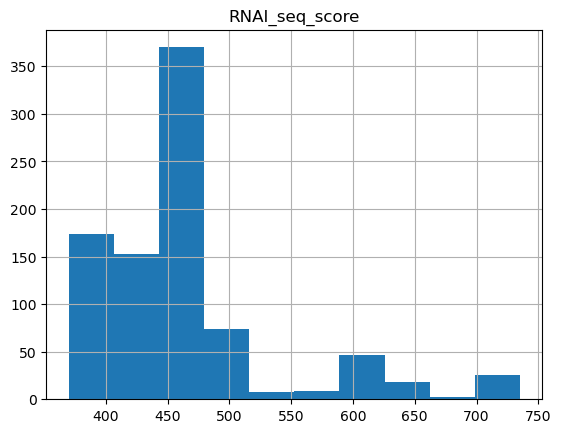

In [25]:
df.hist(column="RNAI_seq_score")

array([[<AxesSubplot:title={'center':'RNAP_seq_score'}>]], dtype=object)

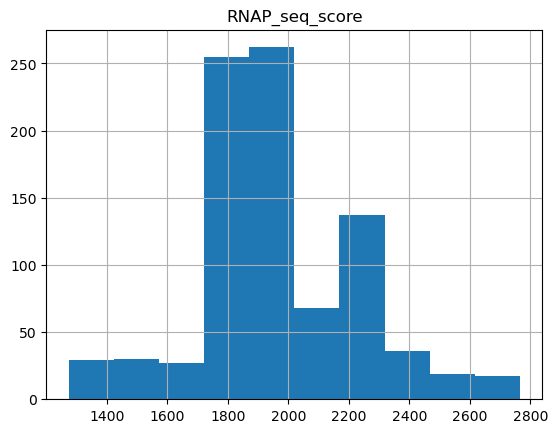

In [26]:
df.hist(column="RNAP_seq_score")

In [27]:
df["genus"].value_counts()

Klebsiella            307
Escherichia           253
Salmonella            117
Enterobacter           61
Yersinia               38
Shigella               28
Citrobacter            23
Aeromonas              10
Raoultella              9
Erwinia                 6
Pantoea                 5
Serratia                4
Cronobacter             3
Pasteurella             2
Vibrio                  2
Hafnia                  2
Leclercia               2
Edwardsiella            2
Rahnella                1
Proteus                 1
Pectobacterium          1
Enterobacteriaceae      1
Pseudomonas             1
Photobacterium          1
Name: genus, dtype: int64

In [28]:
df["family"].value_counts()

Enterobacteriaceae    804
Yersiniaceae           43
Erwiniaceae            11
Aeromonadaceae         10
Hafniaceae              4
Vibrionaceae            3
Pasteurellaceae         2
Pseudomonadaceae        1
Morganellaceae          1
Pectobacteriaceae       1
Name: family, dtype: int64

In [29]:
df["order"].value_counts()

Enterobacterales    864
Aeromonadales        10
Vibrionales           3
Pasteurellales        2
Pseudomonadales       1
Name: order, dtype: int64

array([[<AxesSubplot:title={'center':'RNAI_seq_score'}>]], dtype=object)

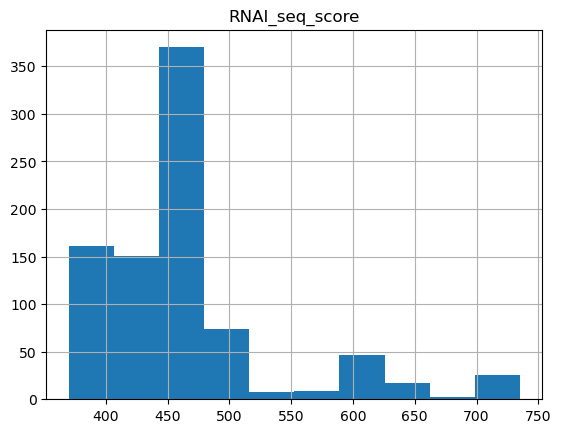

In [30]:
df[df["order"]=="Enterobacterales"].hist(column="RNAI_seq_score")

array([[<AxesSubplot:title={'center':'RNAI_seq_score'}>]], dtype=object)

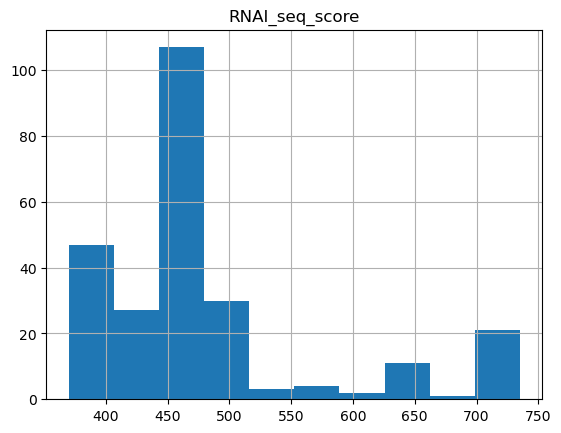

In [31]:
df[df['genus']=="Escherichia"].hist(column='RNAI_seq_score')

In [32]:
df[df["RNAI_seq_score"]>450].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 492 entries, 11 to 879
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   id                       492 non-null    object
 1   species                  492 non-null    object
 2   genus                    492 non-null    object
 3   family                   492 non-null    object
 4   order                    492 non-null    object
 5   RNAI_promoter            492 non-null    object
 6   RNAI_promoter_direction  492 non-null    object
 7   RNAP_promoter            492 non-null    object
 8   RNAP_promoter_direction  492 non-null    object
 9   RNAI_seq_score           492 non-null    int64 
 10  RNAI_seq_start           492 non-null    int64 
 11  RNAI_seq_end             492 non-null    int64 
 12  RNAI_seq_alignmentA      492 non-null    object
 13  RNAI_seq_alignmentB      492 non-null    object
 14  RNAI_seq_direction       492 non-null    

array([[<AxesSubplot:title={'center':'RNAP_seq_score'}>]], dtype=object)

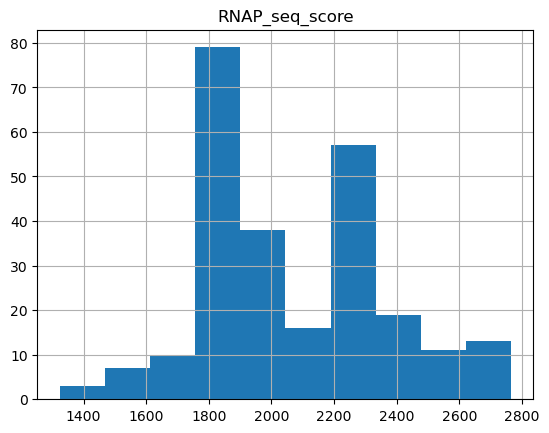

In [33]:
df[df["genus"]=="Escherichia"].hist(column="RNAP_seq_score")